## Name: Varshitha Sai

## Github repository link: 
https://github.com/vvarshhh/ML-fundamentals-2026

## Task 1: Identify the Prediction Target




Question: Inspect the dataset and identify which column should be treated as the target variable for this assignment

Answer: y should be treated as the target variable for this assignment


Question: Justify why this column represents the appropriate prediction objective in the context of the marketing
campaign

Answer: This column represents the appropriate prediction objective because it directly answers the problem which asks to predict whether the client subscribes to a term deposit

Question: Identify at least two other variables that could superficially appear to be valid targets and explain why they
should not be treated as the prediction objective

Answer: Duration might appear to be a valid target because the longer the duration, more likely that the client was interested and it is more likely for them to subscribe to the bank deposit, hence, it highly correlates with subscription of term deposit. However, duration is partially influenced by the client’s decision itself is performed at the time of contact and hence, this leads to data leakage as it incorportaes post-outcome information.

Another variable is poutcome of the call, which correlates highly with whether client subscribes to a term deposit is poutcome which decides whether the previous campaign was successful. This is because past campaign behaviour may seem to predict furture behaviour. However, it is already known at the time of prediction. Using it as the target would redefine the problem into predicting past behavior rather than forecasting current campaign subscription, which does not align with the business objective

## Task 2: Data Loading and Exploration


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

Question: Load the dataset into a Pandas dataframe

In [40]:
bank_data = pd.read_csv("bank-additional.csv", sep=";")

Question: Identify which variables are numerical and which are categorical

Categorical Variables: Job, Martial, Education, Default, Housing, Loan, Contact, Month, day_of_week, poutcome

Numeric: Age, duration, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

In [41]:
df = pd.DataFrame(bank_data)

In [42]:
print(f"Observations: {df.shape[0]}")
print(f"Features: {df.shape[1]}")
print("\nData Types")
print(df.dtypes.value_counts())
print("\nSummary Statistics (Numerical)")
display(df.describe())

Observations: 4119
Features: 21

Data Types
object     11
int64       5
float64     5
Name: count, dtype: int64

Summary Statistics (Numerical)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Question: Analyze the distribution of the target variable and comment on potential class imbalance:

Answer: There is a significantly larger number of no compared to yes, which means that majority of the people do not subscribe to the term deposit. Hence, the dataset is highly imbalanced. Using accuracy as a evaluation metric may be misleading, because if there is a naive model that predicts no all the time, it would around 70-80% correct due to the imbalanceness of the data.

In [43]:
df['y'].value_counts(dropna=False)

y
no     3668
yes     451
Name: count, dtype: int64

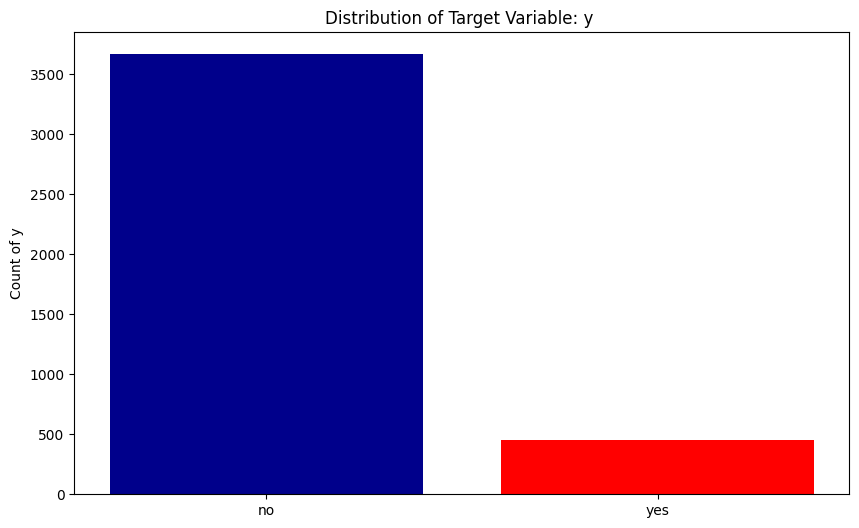

Percentage of 'yes' classes: 10.95%


In [61]:
target_counts = df['y'].value_counts(dropna=False)
plt.figure(figsize=(10, 6))
plt.bar(target_counts.index, target_counts.values, color=['darkblue', 'red'])
plt.title('Distribution of Target Variable: y ')
plt.ylabel('Count of y')
plt.show()

imbalance_ratio = (target_counts['yes'] / df.shape[0]) * 100
print(f"Percentage of 'yes' classes: {imbalance_ratio:.2f}%")

Question: Detect explicit and implicit missing values (eg. soecial categories such as unknown)

In [63]:
print("Explicit Missing Values")
display(df.isnull().sum().sum())

print("\nImplicit Missing Values ('unknown') ")
for col in df.columns:
    u_count = (df[col] == 'unknown').sum()
    if u_count > 0:
        print(f"{col}: {u_count} ({u_count/df.shape[0]*100:.2f}%)")

Explicit Missing Values


np.int64(0)


Implicit Missing Values ('unknown') 
job: 39 (0.95%)
marital: 11 (0.27%)
education: 167 (4.05%)
default: 803 (19.50%)
housing: 105 (2.55%)
loan: 105 (2.55%)


Visualise the distribution of at least:
- Two numerical variables 
- Two categorical variables

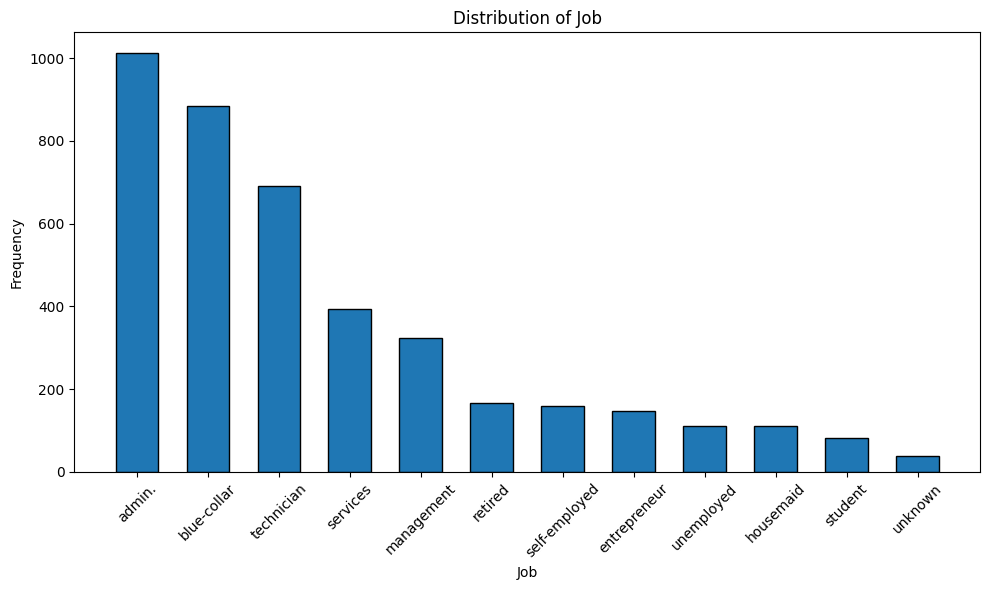

In [46]:
# Used Count plots for categorical data
job_counts = df['job'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(job_counts.index, job_counts.values, width=0.6, edgecolor='black')

plt.title('Distribution of Job')
plt.xlabel('Job')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

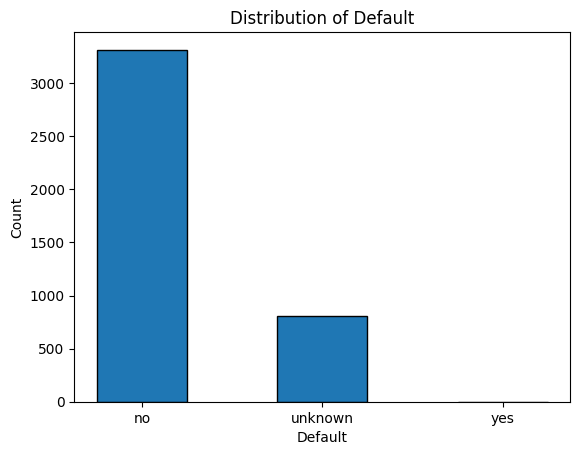

In [47]:
# For binary categorical, Bar plot
counts = df['default'].value_counts()

plt.bar(counts.index, counts.values, width=0.5, edgecolor='black')
plt.title('Distribution of Default')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

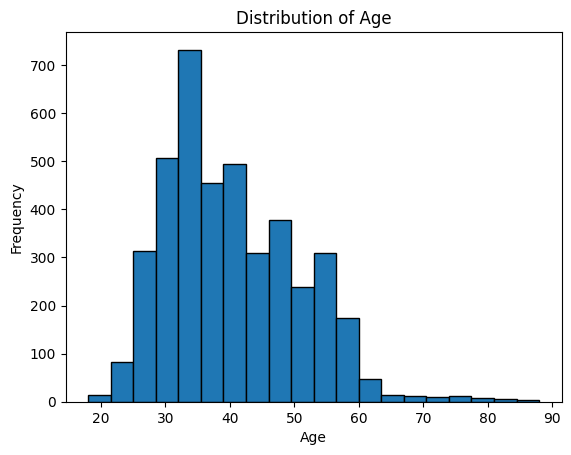

In [48]:
# Histogram for numeric variables
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

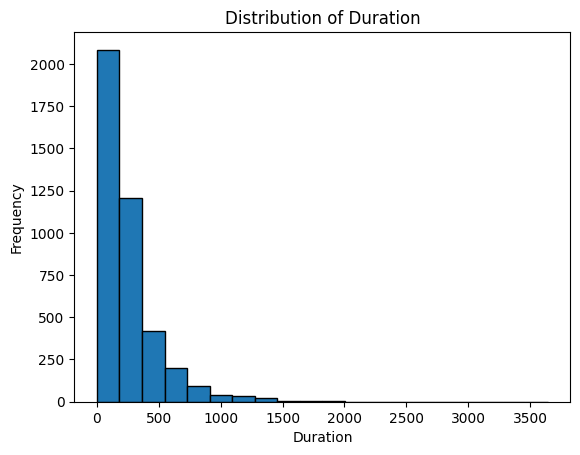

In [49]:
# Histogram for numeric variables
plt.hist(df['duration'], bins=20, edgecolor='black')
plt.title('Distribution of Duration')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

Question: Identify at least one variable that may require special consideration before modeling (e.g., due to distributional
properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.

Answer: Variable duration may require special consideration and should be removed because it would give unrealistic predictions  as the model is getting information it shouldn't have and duration will be known only after a call, hence, this results in data leakage. The variable duration should be removed from the training set.

Another variable that may require special consideration is pdays as many of the values for pdays are 999 it creates extreme skewness and requires special encoding or conversion (e.g., to a binary 'previously_contacted' vs 'never_contacted').

## Task 3: Data Splitting

Question: Justify your choice of proportions for each split

Answer: I have chosen to split the data to 70:15:15 ratio, 70% of the data to train, 15% to test and 15% to validate the data. 70% of the data is used to train to give more data for the model to learn from as the dataset is not that that big and for the rest we can equally split between validation and test set to give just enough data to tune reliably and evaluate fairly respectively. 



Question: Perform stratified splitting with respect to the target variable and explain why stratification is necessary for this dataset

Answer: Stratification is required for this dataset as there is uneven number of yes and no for the target variable and we need to ensure that same number of yes and no for all three, test, train and validation dataset is reflected.



In [50]:
# Split data into features and target
X = df.drop('y', axis = 1)

# Create binary target for computations
Y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Train 70% test 30%
X_train, X_temp, Y_train, Y_temp = train_test_split( X, Y, test_size=0.30,stratify=Y,random_state=42)
# split validation and test equally
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp,test_size=0.50,stratify=Y_temp,random_state=42)

Question: Clearly describe at which stage of your pipeline the split must occur and explain what types of data leakage would arrise if splitting were performed later

Answer: The split must occur right after loading the data. Statistical leakage might occur. This is because once the information is fully processed(such as filling missing values, scaling dataset) some data from test set can leak into training set. This means that any form of statistical analysis done before the train test split can cause the training data to understand and know about teh testing data which can result in lower reliability of outcome as model evaluation becomes overly optimistic. 

# Task 4: Managing Missing Values

Question: Identify both explicit missing values (e.g., NaN) and implicit missing values (e g., categories such as unknown
or sentinel numerical values, i.e., values that may represent special codes rather than genuine measurements)

Answer: The implicit missing values are either labelled as unknown under default column and nonexistent from poutcome. The explicit missing values are pdays = 999 (a large number) which means that they were previously not contacted. 

Question: Quantify the extent of missingness for each a!ected variable.

Answer: For unknown under default column it is not that many values that are missing. However for both pdays= 999 and nonexistent from poutcome , majoirity of the values from the column are filled with these missing values 

Question:  Propose and justify a strategy for handling missing values in each case (e.g., removal, imputation, separate
category, indicator variable) and clearly state which operations must be fitted using the training set only, and explain why

Answer: 
For Categorical "unknown" variables:
- Keep "unknown" as a seperate category as it may contain a predictive signal and removing it means we will lose data. This is a modelling decision as missingness itself may carry useful information.
- Must be fitted using the training set only to prevent model from seeing test categories in advance

For pdays = 999:
- Since majority of the data is pdays = 999 (which means that they were never contacted) or a small numerical value, we can create an indicator binary variable for 1 if they were never contacted (pdays = 999) and 0 if they were never contacted (pdays != 999). If 999 is left as it is, the model might think that it is a very large number and will distort the scaling and learning. This is both data cleaning (correcting the artifical value 999) and modeling decision (missingness carries signal)
- Must be fitted using the training set only to to prevent statistics (mean, std) from including test data to avoid leakage

For nonexistent from poutcome:
- Since majority of the data contains nonexistent from the poutcome column, we can introduce a seperate category nonexistent. Nonexistent indicates that client was not contacted before and this could be predictive information
- Must be fitted using the training set only to to prevent model from learning mapping from unseen categories in test

## Task 5:  Encoding Categorical Variables

Question: Identify all categorical variables in the dataset.

Answer: Categorical Variables: Job, Martial, Education, Default, Housing, Loan, Contact, Month, day_of_week, poutcome

Question: Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables (categories with a meaningful order, e.g., education level), and justify your classification.

Answer:

Nominal variables: Job, Martial, Contact, poutcome, Housing, Loan,  Month, day_of_week

Ordinal variables: Education

The order of Job, Martial, Contact, poutcome, Housing, Loan,  Month, day_of_week does not matter whereas the order of the ordinal variables which have meaning with different levels of education (increasing level of education).



Question: Select and apply an appropriate encoding strategy for each categorical variable.

Answer: Utilise one-hot encoding for all the categorical variables. Since most ML algorithms operate on numerical vectors and cannot directly consume categorical values. One-hot encoding works as it turns categories into 0/1 numbers, each category receives its own coefficient and does not force the model to think that one category is “higher” or “lower” than another. This aligns with logistic regression’s mathematical form and avoids imposing artificial ordering or linear trends that would occur with numeric label encoding.


Question: Clearly state which encoders must be fitted on the training set only, and explain why
Answer: All the encoders must be fitted on training set to prevent any data leakage.

Question: 

Analyze how encoding changes:
- the dimensionality of the dataset;
- the interpretability of model coe”cients;
- the types of decision boundaries a linear model can represent.

Answer:

Encoding increases dimensionality of the dataset and each category gets its own coefficient and allows for linear boundary across category indicators.

In [51]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [52]:
# Apply encoding strategy
nominal_vars = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
ordinal_var = 'education'

# Define Ordinal Scale
edu_levels = ['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree']

# Encoders
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
oe = OrdinalEncoder(categories=[edu_levels])

# Fit on Train Only
ohe.fit(X_train[nominal_vars])
oe.fit(X_train[[ordinal_var]])

def preprocess_categorical(df_in, ohe_obj, oe_obj):
    # OHE
    ohe_cols = ohe_obj.get_feature_names_out(nominal_vars)
    ohe_data = ohe_obj.transform(df_in[nominal_vars])
    ohe_df = pd.DataFrame(ohe_data, columns=ohe_cols, index=df_in.index)
    
    # Ordinal
    ord_data = oe_obj.transform(df_in[[ordinal_var]])
    ord_df = pd.DataFrame(ord_data, columns=[ordinal_var], index=df_in.index)
    
    # Remove originals and concat
    df_rest = df_in.drop(nominal_vars + [ordinal_var], axis=1)
    return pd.concat([df_rest, ohe_df, ord_df], axis=1)

X_train_enc = preprocess_categorical(X_train, ohe, oe)
X_val_enc = preprocess_categorical(X_val, ohe, oe)
X_test_enc = preprocess_categorical(X_test, ohe, oe)

print(f"Total features after encoding: {X_train_enc.shape[1]}")

Total features after encoding: 56


## Task 6: Feature Selection

Question: Identify and remove features with low variance, if any. Justify criterion used to define "low" variance

Answer: I have set the variance threshold of < 0.01 to define as low variance and any features with variance lower than that will be removed. One hot encoding was performed on categorial columns to convert them to numeric to get the variance. Hence, the column names have changed and hence the columns removed were: 'job_unknown', 'marital_unknown', 'education_illiterate', 'default_yes', 'month_dec'



Question:  Identify highly correlated numerical features and decide whether any should be removed. Clearly state the threshold used and justify your decision.

Answer: Variable duration may ashould be removed because it would give unrealistic predictions  as the model is getting information it shouldn't have and duration will be known only after a call, hence, this results in data leakage. The variable duration should be removed from the training set.


Question: Discuss whether any features should be removed based on conceptual considerations (e.g., redundancy, availability at prediction time, or risk of data leakage)

Answer: Columns to be removed are euribor3m,nr.employed, loan_unkown, loan_yes, contact_telephone, poutcome_success as they are higher than 0.9. I used a threshold of 0.9 because higher than 0.9 correlation means very strong linear dependence between the features. 0.9 balances redundancy reduction without discarding moderately correlated but informative features.

Question: Explain why feature selection must be performed using the training set only ans discuss the consequences of performing feature selection on the entire dataset before splitting

Answer: The training set represents the data the model will learn from, while the test set simulates unseen data.If you perform feature selection on the entire dataset, you risk data leakage. Information from the test set influences which features are chosen. The model “sees” the test data, inflating performance metrics.By selecting features on training data only, you ensure that your evaluation on the test set remains unbiased, giving a realistic estimate of model performance.

In [ ]:
# Remove duration to prevent target leak
X_train_enc.drop('duration', axis=1, inplace=True)
X_val_enc.drop('duration', axis=1, inplace=True)
X_test_enc.drop('duration', axis=1, inplace=True)

# Low Variance Check
vars_to_keep = []
for col in X_train_enc.columns:
    # Only for binary/categorical features from OHE mainly
    if X_train_enc[col].var() > 0.01: # Threshold for 'low' variance
        vars_to_keep.append(col)

print(f"Features dropped due to low variance: {X_train_enc.shape[1] - len(vars_to_keep)}")
X_train_sel = X_train_enc[vars_to_keep]
X_val_sel = X_val_enc[vars_to_keep]
X_test_sel = X_test_enc[vars_to_keep]

# High Correlation Check
corr_matrix = X_train_sel.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print(f"Features dropped due to high correlation (>0.9): {to_drop}")
X_train_sel.drop(to_drop, axis=1, inplace=True)
X_val_sel.drop(to_drop, axis=1, inplace=True)
X_test_sel.drop(to_drop, axis=1, inplace=True)

Features dropped due to low variance: 4
Features dropped due to high correlation (>0.9): ['euribor3m', 'nr.employed', 'default_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'poutcome_success']


C:\Users\saiva\AppData\Local\Temp\ipykernel_3992\2228213682.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_sel.drop(to_drop, axis=1, inplace=True)
C:\Users\saiva\AppData\Local\Temp\ipykernel_3992\2228213682.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val_sel.drop(to_drop, axis=1, inplace=True)
C:\Users\saiva\AppData\Local\Temp\ipykernel_3992\2228213682.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test

## Task 7: Feature Scaling

Question: Identify the numerical variables that require scaling.
Answer: The numeric variables that require scaling are : duration, pdays, euribor3m, nr.employed, cons.price.idx, cons.conf.idx


Question: Select and apply an appropriate scaling strategy (e.g., standardization or normalization) to those variables. Justify your choice of scaling method in the context of Logistic Regression.

Answer: Standardization works better for these variables as standardization works better for linear models like logistic regression which compute a linear combination of features and Gradient-based optimizers work best when features are centered around 0 and on similar scale. Hence, this ensures fair coefficient regularization and helps gradient descent converge faster.



Question: Clearly state which transformations must be fitted on the training set only, and explain why.

Answer: Transformations like imputation, feature scaling, categorical encoding, and feature selection must be fitted only on the training set. This is done to prevent data leakage, where information from the "unseen" test or validation sets (such as global means or category mappings)  influences the training process


Question: Discuss how feature scaling affects:
- gradient-based optimization
- the magnitude and comparability of model coe”cients
- the interpretation of regularization penalties

Answer: Feature scaling balances gradient so that there is faster and more stable convergence. It ensures the the coefficient magnitude is more comparable across model coefficient. There is a fair interpretation of regularization penalities.

In [55]:
scaler = StandardScaler()
scaler.fit(X_train_sel)

X_train_scaled = pd.DataFrame(scaler.transform(X_train_sel), columns=X_train_sel.columns, index=X_train_sel.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_sel), columns=X_val_sel.columns, index=X_val_sel.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_sel), columns=X_test_sel.columns, index=X_test_sel.index)

## Task 8: Addressing Class Imbalance

Question: Quantify the class distribution in the training set and explain why imbalance is or is not a concern for this
prediction task.

Answer: Majority of the people have not subscribed to a term deposit (about 85%) only the minority have subscribed to the term deposit. Imbalance as it can lead to skewed model performance, because the "no" class dominates, the model may become "uselessly efficient" by prioritizing the majority class, while the minority class (the "yes" subscribers) remains underrepresented and poorly predicted. Lastly, in this task, the bank's primary interest is identifying the minority "yes" cases to drive term deposit subscriptions. Missing these (False Negatives) is often more costly than misidentifying a non-subscriber.





Question:  Propose and apply a resampling strategy (e.g., random oversampling, SMOTE, or ADASYN). Clearly justify
at which stage of the pipeline the resampling step should occur. Justify your choice of resampling method in terms of its assumptions and expected e!ect on the learning
algorithm.

Answer: A recommended resampling strategy would be  random oversampling as it is a non-parametric method that doesn't make assumptions about the data structure. Unlike SMOTE (which uses k-nearest neighbors), it doesn't risk creating "bridge" samples between clusters of different classes in noisy regions. Because it only duplicates existing real observations, it doesn't introduce synthetic data points that might be physically impossible or mathematically unrealistic in high-dimensional space



Question: Explain what would happen if resampling were applied before splitting the dataset into training, validation,
and test sets. Discuss the implications for model evaluation.

Answer: If resampling were applied before splitting the dataset into training, validation, and test sets it would result in data leakage as the model would know about the new data introduced in the test set and this can lead to overly optimistic accuracy or evaluation metric.



Question: Briefly discuss how class imbalance affects evaluation metrics such as accuracy, precision, and recall.

Answer: Class imbanace can lead to misleading accuracy. If a model simply predicts "no" for every client, it would achieve roughly 85% accuracy without actually learning any patterns or identifying a single potential subscribe. Class imbalance lowers precision for the minrity class (the yes class for the problem) and may may either under-predict it (few TPs) or over-predict positives incorrectly (more FPs), both of which hurt the precision metric. Class imbalance also reduces recall for the minority class, because the model tends to miss many actual positives, predicting mostly the majority class instead.

In [56]:
from sklearn.utils import resample

# Combine training data for resampling
train_data = pd.concat([X_train_scaled, Y_train], axis=1)

df_majority = train_data[train_data.y == 0]
df_minority = train_data[train_data.y == 1]

# Upsample minority class
df_minority_upsampled = resample(
    df_minority,
    replace=True, 
    n_samples=len(df_majority), 
    random_state=42
)

train_balanced = pd.concat([df_majority, df_minority_upsampled])
X_train_bal = train_balanced.drop('y', axis=1)
y_train_bal = train_balanced.y

print(f"Balanced Training Set Size: {len(X_train_bal)}")
print(f"Ratio: {y_train_bal.mean():.2f}")

Balanced Training Set Size: 5134
Ratio: 0.50


## Task 9:  Training a Regression Model

Question: Compare the model’s accuracy with the Zero Rule baseline and briefly interpret the result

Answer: The Zero Rule achieves higher accuracy by simply predicting 'no' for every single person. However, this model is useless for the bank because it misses 100% of the subscribers (0% Recall). Our Logistic Regression model has slightly lower accuracy, but it achieves a Recall of around 60%. This means it actually succeeds in its primary goal: identifying the majority of the customers who are likely to subscribe. In imbalanced datasets like this one, Recall is the more important metric for real-world utility.

The diagram shows that by using Logistic Regression for an imbalanced dataset, you are choosing to accept more False Positives (top-right) in order to capture more True Positives (bottom-right).  For a bank, the cost of making a phone call to a "False Positive" is much lower than the profit lost by missing a "True Positive." Therefore, the diagram proves that your model is business-effective, even though its "Accuracy" is lower than the 89% Zero Rule baseline.

Validation Results
Accuracy:  0.8333 (Zero Rule: 0.8900)
Precision: 0.3554
Recall:    0.6324


[Text(0, 0, 'Does not subscribe'), Text(0, 1, 'Subscribes')]

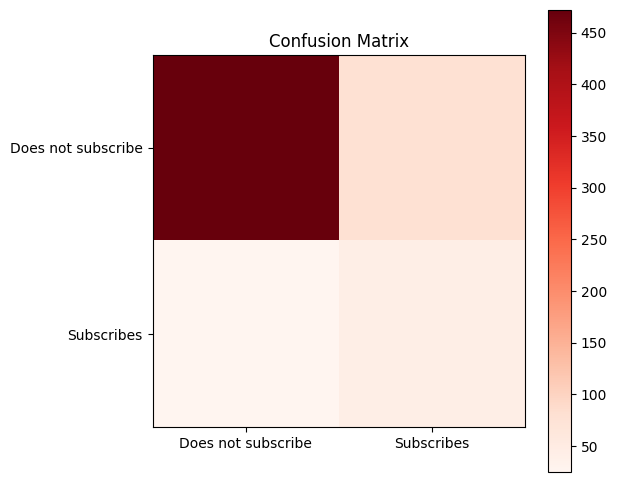

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score

# Using class_weight='balanced' to force the model to prioritize the minority class
model = LogisticRegression(random_state = 42, solver = 'liblinear', class_weight='balanced')
model.fit(X_train_bal, y_train_bal)

# Validate
y_pred = model.predict(X_val_scaled)

# Metrics
acc = accuracy_score(Y_val, y_pred)
prec = precision_score(Y_val, y_pred)
rec = recall_score(Y_val, y_pred)
zero_rule_acc = (Y_val == 0).mean()

print("Validation Results")
print(f"Accuracy:  {acc:.4f} (Zero Rule: {zero_rule_acc:.4f})")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")

# # Confusion Matrix Visualization 
cm = confusion_matrix(Y_val, y_pred)
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
ax.set_title("Confusion Matrix")
fig.colorbar(im)

classes = ['Does not subscribe', 'Subscribes']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)


## Task 10: Task Odering

Question:  Determine the correct order in which the data preparation tasks in this assignment should be performed.  Provide a structured justification for your chosen order

Answer: The data preparation pipeline followed a strict sequence to avoid data leakage and ensure a valid machine learning workflow, the data preparation tasks must follow a logically structured pipeline and to ensure logical dependency.Missing values must be handled before encoding/scaling, encoding must occur before scaling, Feature selection must precede scaling, Resampling must occur after scaling.
- Tasks order:
    - Task 1: Identifitying the Prediction Target
    - Task 2: Data Loading and Exploration
    - Task 3: Data Splitting
    - Task 4: Managing Missing Values
    - Task 5: Encoding Categorical Variables
    - Task 6: Feature Selection
    - Task 7: Feature Scaling
    - Task 8: Addressing Class Imbalance
    - Task 9: Training a Logistic Model
    - Task 10: Task Odering

Question: For each step in your proposed sequence, explain:
- what information is allowed to be used at that stage;
- what information must not be used;
- what type of data leakage could occur if the order were changed.

### Task 1: Identify the Prediction Target

Allowed:
- Business objective
- Full list of variables
- Domain knowledge

Not allowed:
- Choosing the target based on predictive strength after modelling
- Using model performance to justify the target

Leakage risk if order changes:
- Target selection bias: The modelling objective becomes influenced by observed outcomes.

### Task 2: Data Loading and Exploration

Allowed:
- Full dataset for understanding structure
- Class distribution
- Identify and Analyse distribution

Not allowed:
- Fitting preprocessing transformations before splitting
- Computing statistics that will later be reused

Leakage risk:
- Train-test contamination and leakage if preprocessing decisions are based on full-dataset statistics.

### Task 3: Data Splitting

Allowed:
- Entire dataset to create random or stratified split

Not allowed:
- Applying scaling, encoding, imputation, or resampling before splitting

Leakage risk:
- Direct data leakage from test to train, leading to overly optimistic performance estimates.

### Task 4: Managing Missing Values

Allowed:
- Identify missing values
- Quantification and Justification of missing values

Not allowed:
- Using test set statistics to compute values

Leakage risk:
- Statistical leakage if imputation parameters reflect test distribution


### Task 5: Encoding Categorical Variables

Allowed:
- Categories present in training data
- Encoder fitted only on training set

Not allowed:
- Fitting encoder on full dataset

Leakage risk:
- Future information leakage if training data is influenced by categories seen only in the test set.

### Task 6: Feature Selection

Allowed:
- Correlation and variance analysis on training set
- Conceptual reasoning about redundancy and leakage

Not allowed:
- Performing selection using full dataset
- Using test correlations with the target

Leakage risk:
- Selection bias leakage: Features are chosen based on relationships that include test data.


### Task 7: Feature Scaling

Allowed:
- Training set mean and standard deviation

Not allowed:
- Scaling done on full dataset (include test and validation datsets)

Leakage risk:
- Distributional leakage — training data reflects test distribution statistics.

### Task 8: Addressing Class Imbalance

Allowed:
- Resampling methods applied only to training data


Not allowed:
- Resampling before splitting
- Modifying class distribution in the test set

Leakage risk:
- Data duplication leakage if synthetic or duplicated samples appear in both train and test sets.

### Task 9: Training a Regression Model

Allowed:
- Processed training data
- Training labels
- Validation of the training data

Not allowed:
- Using test labels during training
- Adjusting model decisions based on test performance

Leakage risk:
- Evaluation leakage and overfitting to the test set.

Question: Discuss at least one example of an incorrect ordering and explain the consequences it would have on model
evaluation.


Answer:
If you scale based on the global mean and standard deviation of the full dataset, the training data learns information about the distribution of the test set. Your model evaluation will show deceptively high accuracy or low error rates because the model understands the range and variance of the test data. Moroever, when the model learns a specific distribution it shouldn't know, it leads to a system that performs significantly worse in a real-world production environment where it encounters truly unseen data. Lastly, the evaluation metrics no longer reflect the model's actual predictive power, making it impossible to trust the results of the cross-validation.

